In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Filling the missing values

In [ ]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Age'] = df.groupby('Title')['Age'].transform(lambda x:x.fillna(x.median()))

KeyError: 'Title'

In [35]:
df['Deck'] = df['Cabin'].astype(str).str[0]
df['Deck'] = df['Deck'].replace('N','U')

In [36]:
df.Deck

0      n
1      C
2      n
3      C
4      n
      ..
886    n
887    B
888    n
889    C
890    n
Name: Deck, Length: 891, dtype: object

In [39]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Deck           0
dtype: int64

In [38]:
df.drop('Cabin', axis=1, inplace=True)

In [11]:
df['Embarked'] = df['Embarked'].fillna(df.Embarked.mode()[0])

In [12]:
df = pd.read_csv('Titanic-Dataset.csv')
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [13]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [27]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [41]:
from sklearn.preprocessing import MinMaxScaler

numerical_val = ['Age','Fare']

minmax = MinMaxScaler()

for i in numerical_val:
    df[i] = minmax.fit_transform(df[[i]])

In [42]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
0,1,0,3,108,1,0.271174,1,0,523,0.014151,2,8
1,2,1,1,190,0,0.472229,1,0,596,0.139136,0,2
2,3,1,3,353,0,0.321438,0,0,669,0.015469,2,8
3,4,1,1,272,0,0.434531,1,0,49,0.103644,2,2
4,5,0,3,15,1,0.434531,0,0,472,0.015713,2,8
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,548,1,0.334004,0,0,101,0.025374,2,8
887,888,1,1,303,0,0.233476,0,0,14,0.058556,2,1
888,889,0,3,413,0,0.346569,1,2,675,0.045771,2,8
889,890,1,1,81,1,0.321438,0,0,8,0.058556,0,2


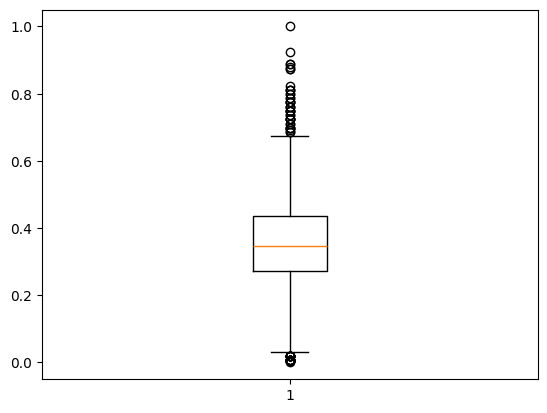

In [31]:
plt.boxplot(df.Age)
plt.show()

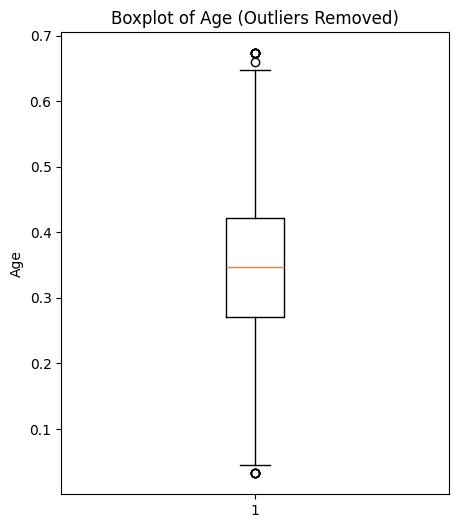

In [ ]:

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_no_outliers = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]


plt.figure(figsize=(5,6))
plt.boxplot(df_no_outliers['Age'].dropna())
plt.title("Boxplot of Age (Outliers Removed)")
plt.ylabel("Age")
plt.show()



In [43]:
variables = ['Ticket','Fare']
for i in variables:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    df_no_outliers = df[(df[i] >= lower_bound) & (df[i] <= upper_bound)]

